<a href="https://colab.research.google.com/github/EzeGB/PythonExcercises/blob/practica-DOZ/practica2DiplomadoCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######**EZEQUIEL GERSTEL BODOHA**

###**Sean las siguientes matrices:**
* ----------------------
A:
*       1   2  -4
*      -5   0   1
*       3   2   3
* ----------------------
B:
*      -4   0   3
*       1   0   2
*      -4   1   8

###**Realizar las siguientes operaciones:**

* Determinante de ambas matrices
* Inversa de ambas matrices (si existe)
* AB
* (B^T @ A^T) ^ T




In [2]:
import numpy as np

In [15]:
matA = np.array ([[1,2,-4],
                 [-5,0,1],
                 [3,2,3]],dtype=np.float64)
matB = np.array ([[-4,0,3],
                 [1,0,2],
                 [-4,1,8]],dtype=np.float64)
matrices = []
matrices.append(matA)
matrices.append(matB)

In [17]:
determinantes = []
inversas = []

for i, matriz in enumerate(matrices):
    determinantes.append(np.linalg.det(matriz))
    print('Matriz:')
    print(matriz)
    print('Determinante:',determinantes[i])
    if determinantes[i] != 0:
        inversas.append(np.linalg.inv(matriz))
    else:
        inversas.append('La matriz no es invertible')
    print('Inversa:')
    print(inversas[i])
    print('--------------------------------')

Matriz:
[[ 1.  2. -4.]
 [-5.  0.  1.]
 [ 3.  2.  3.]]
Determinante: 73.99999999999997
Inversa:
[[-0.02702703 -0.18918919  0.02702703]
 [ 0.24324324  0.2027027   0.25675676]
 [-0.13513514  0.05405405  0.13513514]]
--------------------------------
Matriz:
[[-4.  0.  3.]
 [ 1.  0.  2.]
 [-4.  1.  8.]]
Determinante: 11.000000000000002
Inversa:
[[-0.18181818  0.27272727 -0.        ]
 [-1.45454545 -1.81818182  1.        ]
 [ 0.09090909  0.36363636  0.        ]]
--------------------------------


In [23]:
print('AB:')
print(matA @ matB)
print('-------------------')
print('(B^T @ A^T) ^ T:')
print(((matA.T)@(matB.T)).T)

AB:
[[ 14.  -4. -25.]
 [ 16.   1.  -7.]
 [-22.   3.  37.]]
-------------------
(B^T @ A^T) ^ T:
[[ 5. -2. 25.]
 [ 7.  6.  2.]
 [15.  8. 41.]]


###**Por medio de pyplot, generar gráficos de las siguientes funciones:**

* sinh
* cosh
* x^3 + x^2 + x + 1
* e^x + e^-x



In [24]:
import matplotlib.pyplot as plt
import numpy as np

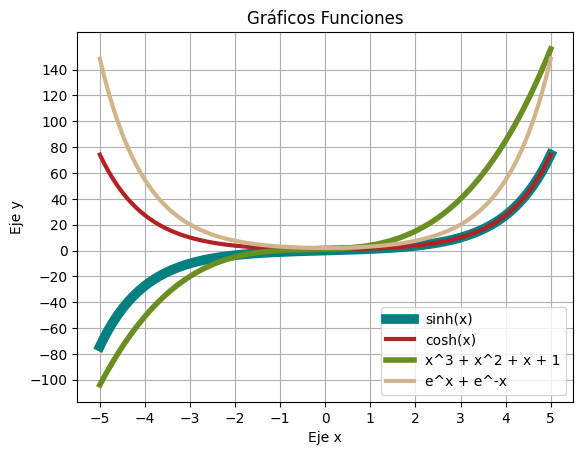

In [25]:
x = np.arange(-5,5+0.1,0.1)
plt.title('Gráficos Funciones')
plt.grid(True)
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.xticks(np.arange(-5, 5+1, 1))
plt.yticks(np.arange(-100, 150+0.1, 20))
plt.plot(x, np.sinh(x), color='teal', linewidth=7, label = "sinh(x)")
plt.plot(x, np.cosh(x), color='firebrick', linewidth=3, label = "cosh(x)")
plt.plot(x, (x ** 3 + x ** 2 + x + 1), color='olivedrab',linewidth=4,  label = "x^3 + x^2 + x + 1")
plt.plot(x, (np.exp(x) + np.exp(-x)), color='tan',linewidth=3, label = "e^x + e^-x")
plt.legend()

###**Por medio de plt.imshow, visualizar al menos tres imágenes de su elección, realizando el recorte de regiones de interés específicas de cada imagen**

In [26]:
from PIL import Image

In [27]:
pinturas = []
pinturas.append(Image.open('monet.jpg'))
pinturas.append(Image.open('goya.jpg'))
pinturas.append(Image.open('beksinsky.jpg'))
for i in range(len(pinturas)):
    pinturas[i] = np.array(pinturas[i])
    print(pinturas[i].shape)

(198, 255, 3)
(266, 189, 3)
(242, 208, 3)


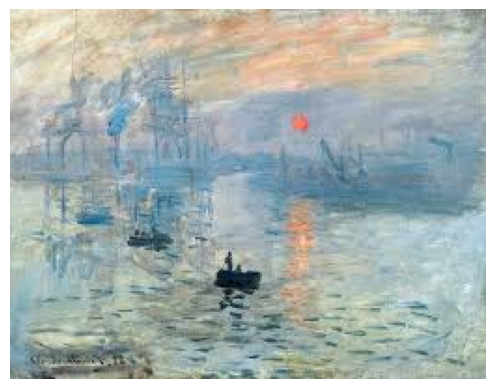

In [28]:
plt.grid(False)
plt.axis('off')
plt.imshow(pinturas[0])

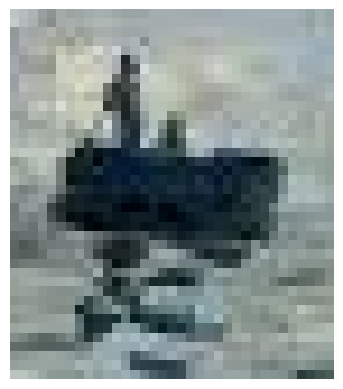

In [29]:
plt.grid(False)
plt.axis('off')
boat = pinturas[0][125:165,105:140]
plt.imshow(boat)

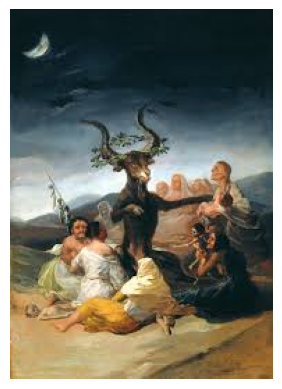

In [30]:
plt.grid(False)
plt.axis('off')
plt.imshow(pinturas[1])

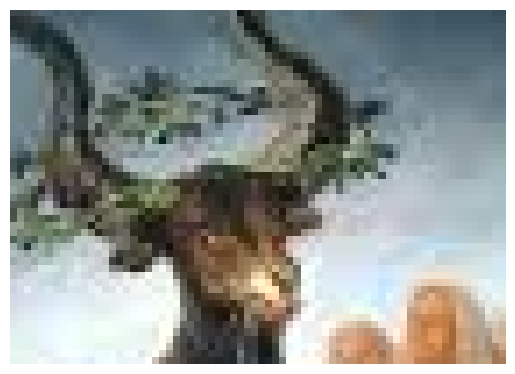

In [31]:
plt.grid(False)
plt.axis('off')
goat = pinturas[1][80:130,60:130]
plt.imshow(goat)

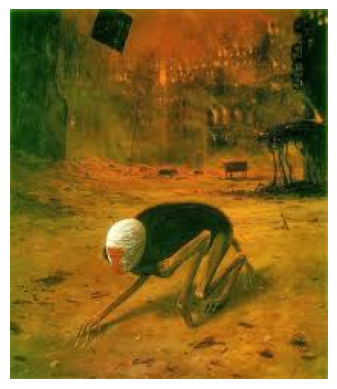

In [32]:
plt.grid(False)
plt.axis('off')
plt.imshow(pinturas[2])

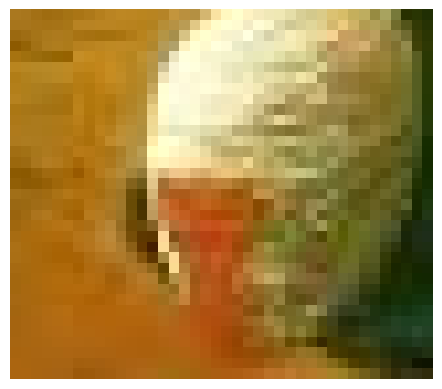

In [33]:
plt.grid(False)
plt.axis('off')
throat = pinturas[2][140:175,50:90]
plt.imshow(throat)

PARTE 2 (PANDAS):

Sean los datasets carrera.csv y estudiantes.csv adjuntos a la tarea, se pide:

* 1 Leer los datasets carreras y estudiantes a partir de los archivos csv
* 2 Mostrar las primeras 5 filas de cada tabla. ¿Qué columnas tiene cada una?
* 3 ¿Cuántos estudiantes tiene el dataset? ¿Cuántas carreras?
* 4 Si existen datos faltantes en Carreras, reemplazarlos con “Administración Turística”
* 5 Estandarizar el nombre de la carrera de tal manera que comience con mayúscula en todos los casos
* 6 ¿Qué valores únicos tiene la columna sexo? ¿Cuáles son inconsistentes?
* 7 Estandarizar los valores de sexo de tal manera que sean únicamente M o F
* 8 ¿Qué valores únicos tiene la columna nivel? Identificar cuáles representan el mismo valor pero están escritos diferente.
* 9 Encontrar los estudiantes cuya fecha_ingreso es anterior a su fecha_nacimiento.
* 10 Eliminar las filas duplicadas de carrera conservando solo la primera aparición. Verificar el resultado.
* 11 Rellenar los valores nulos de apellido y nombre con la cadena "Desconocido".
* 12 Mostrar los estudiantes cuyo id_carrera no se encuentra en la tabla de carreras.


In [117]:
import pandas as pd
import numpy as np

###1 Leer los datasets carreras y estudiantes a partir de los archivos csv

In [126]:
df_estudiantes = pd.read_csv('estudiantes.csv',sep='\t')
df_carreras = pd.read_csv('carrera.csv',sep='\t')


###2 Mostrar las primeras 5 filas de cada tabla. ¿Qué columnas tiene cada una?

In [128]:
print(df_estudiantes.columns)
df_estudiantes.head(10)

Index(['id_estudiante', 'nombre', 'apellido', 'sexo', 'fecha_nacimiento',
       'fecha_ingreso', 'nivel', 'id_carrera'],
      dtype='object')


,id_estudiante,nombre,apellido,sexo,fecha_nacimiento,fecha_ingreso,nivel,id_carrera
0,1001,Ana,García,F,2000-03-15,2019-09-01,Pregrado,1.0
1,1002,Carlos,Mamani,M,1999-07-22,2018-03-01,Pregrado,2.0
2,1003,Lucía,Flores,F,2001-11-08,2020-09-01,Posgrado,3.0
3,1004,Pedro,Quispe,M,1998-05-30,2017-03-01,Pregrado,4.0
4,1005,María,López,Femenino,1997-02-14,2016-09-01,Pregrado,5.0
5,1006,Jorge,NaN,M,2000-09-01,2019-09-01,Pregrado,1.0
6,1007,Valeria,Condori,F,2002-12-25,2021-03-01,pregrado,6.0
7,1008,Luis,Ramos,M,1995-04-18,2014-03-01,Posgrado,2.0
8,1009,NaN,Torres,F,2003-06-07,2022-09-01,Pregrado,8.0
9,1010,Andrés,Vargas,M,1990-01-01,2010-09-01,Doctorado,3.0


In [105]:
print(df_carreras.columns)
df_carreras.head(5)

Index(['id_carrera', 'nombre'], dtype='object')


,id_carrera,nombre
0,1,Ingeniería en sistemas
1,2,Administración de empresas
2,3,Medicina
3,4,Derecho
4,5,Psicología


###3 ¿Cuántos estudiantes tiene el dataset? ¿Cuántas carreras?

In [98]:
print('Cantidad estudiantes:',len(df_estudiantes)-1)
print('Cantidad carreras:',len(df_carreras)-1)
## Se resta 1 por la cabecera

Cantidad estudiantes: 25
Cantidad carreras: 9


### 4  Si existen datos faltantes en Carreras, reemplazarlos con “Administración Turística”

In [99]:
df_carreras_copia = df_carreras.copy()
df_carreras['nombre'] = df_carreras['nombre'].fillna('Administración Turística')
df_carreras

,id_carrera,nombre
0,1,Ingeniería en Sistemas
1,2,Administración de Empresas
2,3,Medicina
3,4,Derecho
4,5,Psicología
5,2,Administracion de Empresas
6,6,Ingeniería Civil
7,7,Administración Turística
8,8,contabilidad
9,9,Ingeniería en Sistemas


###5 Estandarizar el nombre de la carrera de tal manera que comience con mayúscula en todos los casos

In [100]:
df_carreras_copia2 = df_carreras.copy()
df_carreras['nombre'] = df_carreras['nombre'].str.capitalize() #Solo la primera letra es mayuscula
df_carreras.head(5)

,id_carrera,nombre
0,1,Ingeniería en sistemas
1,2,Administración de empresas
2,3,Medicina
3,4,Derecho
4,5,Psicología


###6 ¿Qué valores únicos tiene la columna sexo? ¿Cuáles son inconsistentes?

In [112]:
print(df_estudiantes['sexo'].unique())
print(df_estudiantes['sexo'].value_counts())
#Femenino y masculino son inconsistentes, y falta algunos valores

['F' 'M' 'Femenino' 'masculino' nan]
sexo
F            12
M            11
Femenino      1
masculino     1
Name: count, dtype: int64


###7 Estandarizar los valores de sexo de tal manera que sean únicamente M o F

In [137]:
#Vi mapas en un tutorial uwu
mapa = {'Femenino' : 'F',
        'masculino': 'M',
        'F' : 'F',
        'M':'M'}
df_estudiantes_copia = df_estudiantes.copy()
df_estudiantes['sexo'] = df_estudiantes['sexo'].map(mapa).fillna('No definido')
df_estudiantes.head(5)

,id_estudiante,nombre,apellido,sexo,fecha_nacimiento,fecha_ingreso,nivel,id_carrera
0,1001,Ana,García,F,2000-03-15,2019-09-01,Pregrado,1.0
1,1002,Carlos,Mamani,M,1999-07-22,2018-03-01,Pregrado,2.0
2,1003,Lucía,Flores,F,2001-11-08,2020-09-01,Posgrado,3.0
3,1004,Pedro,Quispe,M,1998-05-30,2017-03-01,Pregrado,4.0
4,1005,María,López,F,1997-02-14,2016-09-01,Pregrado,5.0


In [130]:
df_estudiantes.tail(5)

,id_estudiante,nombre,apellido,sexo,fecha_nacimiento,fecha_ingreso,nivel,id_carrera
21,1021,Rosa,Benítez,No definido,2001-02-28,2020-09-01,Pregrado,5.0
22,1022,Santiago,Vega,M,2002-07-04,2021-03-01,Pregrado,2.0
23,1023,Natalia,Ibáñez,F,1999-06-16,2018-09-01,Maestría,3.0
24,1024,Pablo,Ortiz,M,1990-10-10,2009-03-01,Doctorado,6.0
25,1025,Laura,Núñez,F,2000-01-01,2019-09-01,Pregrado,NaN


###8 ¿Qué valores únicos tiene la columna nivel? Identificar cuáles representan el mismo valor pero están escritos diferente.

In [131]:
print(df_estudiantes['nivel'].unique())
#Pregrado y pregrado son el mismo y se escribieron de forma inconsistente

['Pregrado' 'Posgrado' 'pregrado' 'Doctorado' nan 'Maestría']


###9 Encontrar los estudiantes cuya fecha_ingreso es anterior a su fecha_nacimiento.

In [145]:
encontrados = []
for i,fila in df_estudiantes.iterrows():
    if  fila['fecha_ingreso']<fila['fecha_nacimiento']:
        encontrados.append(fila['id_estudiante'])
df_filtrados = df_estudiantes[df_estudiantes['id_estudiante'].isin(encontrados)]
print(df_filtrados)
##Si el formato es muy raro no funciona T-T

    id_estudiante   nombre apellido sexo fecha_nacimiento fecha_ingreso  \
16           1016   Miguel    Rojas    M         abr-2000    2019-09-01   
19           1019  Daniela  Herrera    F       1997-09-09    1997-03-01   

       nivel  id_carrera  
16  Pregrado         6.0  
19  Pregrado         3.0  


###11 Rellenar los valores nulos de apellido y nombre con la cadena "Desconocido".

In [150]:
df_estudiantes_copia2 = df_estudiantes.copy()
df_estudiantes['nombre'] = df_estudiantes['nombre'].fillna('Desconocido')
df_estudiantes['apellido'] = df_estudiantes['apellido'].fillna('Desconocido')
print(df_estudiantes.iloc[4:9,:])


   id_estudiante       nombre     apellido sexo fecha_nacimiento  \
4           1005        María        López    F       1997-02-14   
5           1006        Jorge  Desconocido    M       2000-09-01   
6           1007      Valeria      Condori    F       2002-12-25   
7           1008         Luis        Ramos    M       1995-04-18   
8           1009  Desconocido       Torres    F       2003-06-07   

  fecha_ingreso     nivel  id_carrera  
4    2016-09-01  Pregrado         5.0  
5    2019-09-01  Pregrado         1.0  
6    2021-03-01  pregrado         6.0  
7    2014-03-01  Posgrado         2.0  
8    2022-09-01  Pregrado         8.0  
